## Homework 2

I chose to use the statsmodels package instead of scikit-learn, since the tasks do not really involve any machine learning, but rather traditional statistics. Also, printing a model summary for statistics is significantly more convenient.

Examples I used to orient myself are found here: https://www.statsmodels.org/dev/examples/notebooks/generated/ols.html

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [ ]:
# load data into a pandas dataframe
df = pd.read_excel('../data_manufacturing.xlsx')

# print the head of the dataframe
df.head()

,API Particle Size,Mill Time,Screen Size,MgSt Supplier,Lactose Supplier,Sugar Supplier,Talc Supplier,Blend Time,Blend Speed,Compressor,Force,Coating Supplier,Coating Viscosity,Inlet Temp,Exhaust Temp,Spray Rate,Atom. Pressure,Dissolution
0,Small,27,4,Smith Ind,James Ind,Sour,Rough,16.043199,59.887383,COMPRESS2,25.466691,Mac,105.361158,107.945228,70.458995,404.603294,61.007068,79.86
1,Small,11,5,Jones Inc,James Ind,Sour,Smooth,14.361549,59.793030,COMPRESS2,24.934062,Mac,100.232484,107.540101,70.823684,407.367163,60.571220,72.82
2,Small,20,4,Jones Inc,Bond Inc,Sour,Rough,14.458745,60.797487,COMPRESS2,25.503908,Down,100.271603,106.605861,69.197350,399.301868,59.088228,74.18
3,Small,13,3,Smith Ind,Bond Inc,Sweet,Smooth,14.412131,59.398624,COMPRESS1,24.787632,Mac,98.008134,106.093734,68.809087,403.733927,58.844630,69.14
4,Small,13,5,Smith Ind,James Ind,Sweet,Smooth,16.111780,59.921639,COMPRESS2,25.316775,Down,97.582630,108.257381,69.447385,396.709347,59.589137,73.30


In [ ]:
# set target and features
target = 'Dissolution'
y = df[target]
X = df.drop(columns=[target])

# one-hot encoding for categorical variables, we include all dtypes to store them in pandas
# in this case we do not need any indices for transforming the columns, since we can directly use the column names for get_dummies
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(float)

# linear regression using statsmodels
X_sm = sm.add_constant(X_encoded)
model = sm.OLS(y, X_sm).fit()
y_pred = model.predict(X_sm)

# calculate RMSE, since statsmodels does not provide it directly
rmse = np.sqrt(mean_squared_error(y, y_pred))

# print results
print(f"RMSE: {rmse:.4f}\n")
print("Statsmodel Summary:")
print(model.summary())

RMSE: 1.0103

Statsmodel Summary:
                            OLS Regression Results                            
Dep. Variable:            Dissolution   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     42.13
Date:                Sat, 09 May 2026   Prob (F-statistic):           7.90e-31
Time:                        20:01:20   Log-Likelihood:                -128.62
No. Observations:                  90   AIC:                             297.2
Df Residuals:                      70   BIC:                             347.2
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

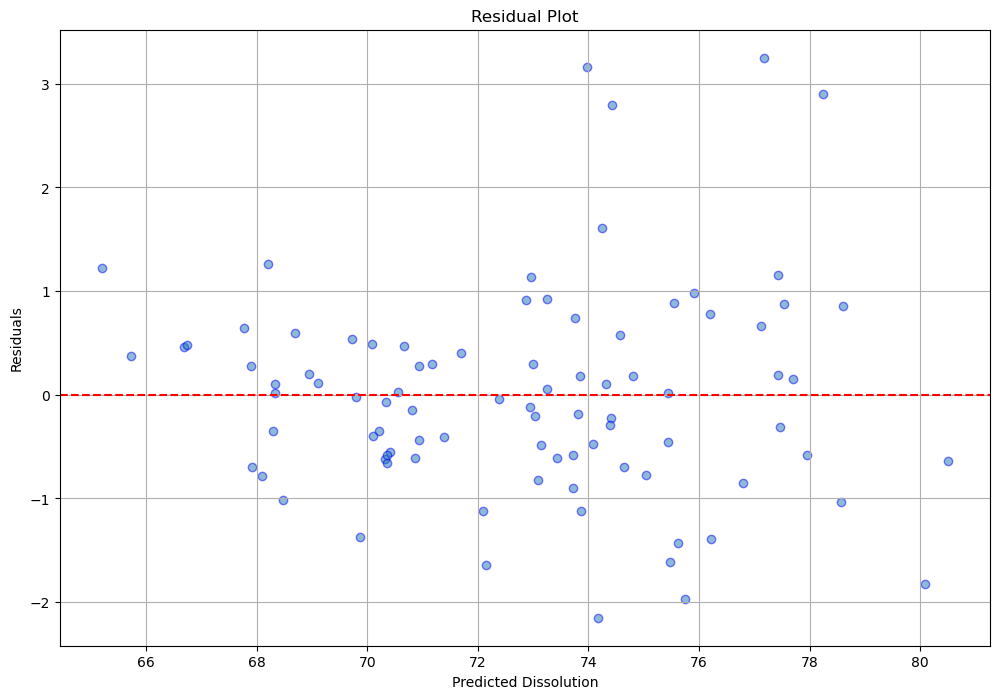

In [24]:
# residual plot
plt.figure(figsize=(12, 8))
plt.scatter(y_pred, model.resid, alpha=0.5, edgecolors='b')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel('Predicted Dissolution')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

## Discussion

- The model reaches an $R^2$ of $0.92$, which shows that the model successfully accounts for 92% of the variance observed in the Dissolution values. The RMSE of $1.0103$ indicates that the standard deviation of the scattering around the regression line is relatively tight.

- The $p$-values show that `Mill Time`, `Screen Size`, `Blend Time`, `Atom. Pressure`, `Sugar Supplier_Sweet`, `Talc Supplier_Smooth`, `MgSt Supplier_Smith Ind` and `API Particle Size_Small` are highly significant ($p<0.05$). Among these, the continuous variables `Mill Time` and `Screen Size` are by far the strongest drivers.

- `Blend Speed`, `Coating Viscosity`, `Inlet Temp`, `Exhaust Temp`, `Spray Rate`, `Compressor`, `Coating Supplier`, `Lactose Supplier`, and `API Particle Size_Medium` are non-significant ($p>0.05$) and could be candidates for removal in a reduced model.

- The residual plot shows points scattered roughly symmetrically around zero with no obvious trend, so the OLS assumptions of zero mean and homoscedasticity seem reasonable. The residual range is small relative to the response scale.

- The high condition number indicates multicollinearity among some predictors. This is likely why several coefficients appear non-significant (e.g. Blend Speed, Inlet Temp, Spray Rate), since correlated variables can mask each other's significance in the model.
